# Experiment Labs 4.b  Probability Distributions 

This notebook has **six scenario questions**, one for each distribution.
Each section follows the same four steps:

| Step | What you get |
|---|---|
| 📘 **Theory** | What the distribution means, in plain words |
| 🧮 **Maths** | The formula, mean, variance and what each symbol means |
| ❓ **Scenario question** | A real-life problem to solve with Python |
| ✅ **Answer** | Hand calculation, Python code, and the plot |

```
                 Probability Distributions
                            │
              ┌─────────────┴─────────────┐
          Discrete                    Continuous
        (you COUNT)                  (you MEASURE)
              │                           │
     ┌────────┼────────┐        ┌───────────────────┐
 Bernoulli Binomial Poisson   Normal             Uniform  
    Q1        Q2      Q3        Q4                  Q5       
```

> 💡 **Tip:** Cover the answer, try the question yourself in the empty cell, then compare.

## Setup
Run this cell first.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from math import comb, factorial, exp

DISCRETE_COLOR = "#0E9F9A"     # teal  → discrete
CONTINUOUS_COLOR = "#E4572E"   # orange → continuous
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
print("Ready!")

Ready!


## Before we start — two key ideas

**Discrete** variables are *counted*. We use a **PMF** (probability mass function):
$P(X = k)$ is the height of a bar, and all bars add up to 1:
$$\sum_k P(X=k) = 1$$

**Continuous** variables are *measured*. We use a **PDF** (probability density function) $f(x)$.
Probability is the **area under the curve**, and the total area is 1:
$$P(a \le X \le b) = \int_a^b f(x)\,dx = F(b) - F(a), \qquad \int_{-\infty}^{\infty} f(x)\,dx = 1$$

Here $F(x) = P(X \le x)$ is the **CDF** (cumulative distribution function). In Python, `stats.<dist>.cdf(...)` gives $F(x)$.

| In Python (`scipy.stats`) | Gives you |
|---|---|
| `.pmf(k, …)` | $P(X = k)$ for discrete distributions |
| `.pdf(x, …)` | Curve height $f(x)$ for continuous distributions |
| `.cdf(x, …)` | $P(X \le x)$ for both |
| `.mean(…)`, `.var(…)` | Mean and variance |

---
# Part A — Discrete distributions

## Q1. Bernoulli distribution

### 📘 Theory
A **Bernoulli trial** is a single experiment with only **two outcomes**:
- **Success** → we write $X = 1$
- **Failure** → we write $X = 0$

Examples: one coin toss, one penalty kick, one exam pass/fail, one email spam/not-spam.

```
      One trial
          │
     ┌────┴────┐
  Success    Failure
  X = 1      X = 0
  prob p     prob 1 − p
```

### 🧮 Maths
$$P(X = x) = p^{x}(1-p)^{1-x}, \qquad x \in \{0,1\}$$

Put in $x=1$: $P(X=1) = p^1(1-p)^0 = p$. Put in $x=0$: $P(X=0) = p^0(1-p)^1 = 1-p$.

| Symbol | Meaning |
|---|---|
| $p$ | Probability of success ($0 \le p \le 1$) |

$$\text{Mean: } E[X] = p \qquad \text{Variance: } Var(X) = p(1-p)$$

*Why is the mean $p$?* $E[X] = 0\cdot(1-p) + 1\cdot p = p$.

### ❓ Scenario question
> ⚽ A footballer scores a penalty **80%** of the time. Let $X = 1$ if she scores and $X = 0$ if she misses.
>
> **(a)** Find $P(X=1)$ and $P(X=0)$.
> **(b)** Find the mean and variance.
> **(c)** Write Python code to **plot the probability distribution** of $X$.

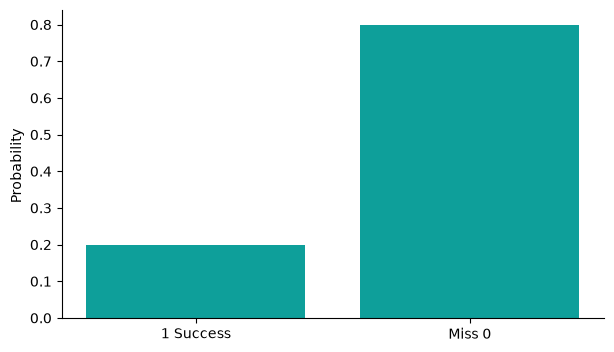

In [32]:
x = [1,0]
p = 0.8
pmf = stats.bernoulli.pmf(x,p)
plt.bar(x,pmf,color=DISCRETE_COLOR)
plt.ylabel("Probability ")
plt.xticks(x,["Miss 0" , "1 Success"])
plt.show()

In [33]:
print(stats.bernoulli.mean(p))
print(stats.bernoulli.var(p))

0.8
0.15999999999999992


### ✅ Answer
**(a)** $p = 0.8$, so $P(X=1) = 0.8$ and $P(X=0) = 1 - 0.8 = 0.2$.

**(b)** $E[X] = p = 0.8$ and $Var(X) = p(1-p) = 0.8 \times 0.2 = 0.16$.

**(c)** Code and plot:

## Q2. Binomial distribution

### 📘 Theory
Repeat a Bernoulli trial **$n$ times** and **count the successes**. That count follows a **Binomial** distribution.

It works only when the **BINS** conditions hold:
- **B**inary — each trial is success or failure
- **I**ndependent — one trial doesn't affect another
- **N**umber of trials $n$ is fixed
- **S**ame probability $p$ every time

```
Trial:    1   2   3   4   5  ...  n
Result:   ✔   ✘   ✔   ✔   ✘  ...  ✔     →  X = number of ✔
```

### 🧮 Maths
$$P(X = k) = \binom{n}{k}\,p^{k}\,(1-p)^{\,n-k}, \qquad k = 0,1,\dots,n$$

| Part | Meaning |
|---|---|
| $\binom{n}{k} = \dfrac{n!}{k!(n-k)!}$ | Number of ways to choose **which** $k$ trials are successes |
| $p^k$ | Probability of the $k$ successes |
| $(1-p)^{n-k}$ | Probability of the $n-k$ failures |

$$\text{Mean: } E[X] = np \qquad \text{Variance: } Var(X) = np(1-p)$$

### ❓ Scenario question
> 💡 A factory makes light bulbs and **10%** of them are faulty. A box contains **15** bulbs.
> Let $X$ = number of faulty bulbs in the box.
>
> **(a)** Find $P(X = 2)$ by hand.
> **(b)** Find the mean and variance.
> **(c)** Write Python code to **plot the distribution** for $k = 0$ to $15$.


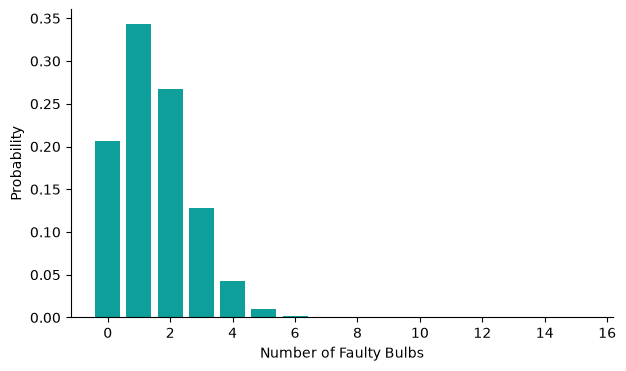

In [17]:
n=15
k=np.arange(0,n+1)
p=0.10
pmf=stats.binom.pmf(k,n,p)
plt.bar(k,pmf,color=DISCRETE_COLOR)
plt.ylabel("Probability")
plt.xlabel("Number of Faulty Bulbs")
plt.show()

In [19]:
print(stats.binom.mean(n,p))
print(stats.binom.var(n,p))

1.5
1.35



### ✅ Answer
Here $n = 15$ and $p = 0.1$.

**(a)**
$$P(X=2) = \binom{15}{2}(0.1)^2(0.9)^{13} = 105 \times 0.01 \times 0.2542 \approx 0.2669$$

**(b)** $E[X] = np = 15 \times 0.1 = 1.5$ and $Var(X) = np(1-p) = 1.5 \times 0.9 = 1.35$.



## Q3. Poisson distribution

### 📘 Theory
The **Poisson** distribution counts **how many times an event happens in a fixed interval** of time or space, when:
- events happen **independently**, and
- they happen at a steady **average rate** $\lambda$ (lambda).

Examples: calls per hour, accidents per month, typos per page, customers per minute.

```
One night (fixed interval)
|──●────────●──●──────────●────|   →  X = 4 events
```

### 🧮 Maths
$$P(X = k) = \frac{\lambda^{k}\,e^{-\lambda}}{k!}, \qquad k = 0,1,2,\dots$$

| Symbol | Meaning |
|---|---|
| $\lambda$ | Average number of events per interval |
| $e$ | Euler's number ≈ 2.718 |
| $k!$ | $k \times (k-1) \times \dots \times 1$ (and $0! = 1$) |

$$\text{Mean: } E[X] = \lambda \qquad \text{Variance: } Var(X) = \lambda$$

⭐ A special property: **mean = variance**.

### ❓ Scenario question
> 🏥 A hospital receives on average **4 emergency cases per night**.
> Let $X$ = number of emergency cases on one night.
>
> **(a)** Find the probability of a **quiet night** (no cases).
> **(b)** Find the probability of **exactly 4** cases.
> **(c)** Write Python code to **plot the distribution** for $k = 0$ to $12$.


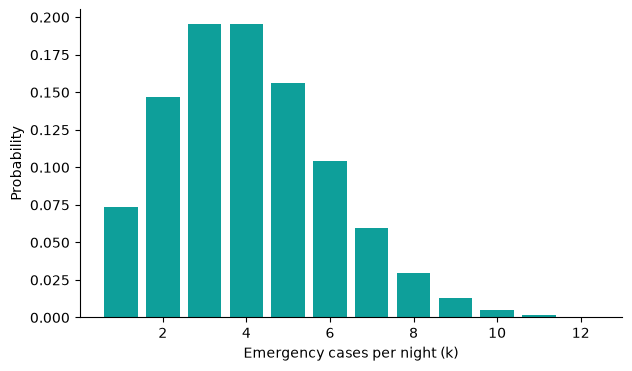

4.0
4.0


In [31]:
la=4
n=12
k=np.arange(1,n+1)
pmf=stats.poisson.pmf(k,la)
plt.bar(k,pmf,color=DISCRETE_COLOR)
plt.xlabel("Emergency cases per night (k)")
plt.ylabel("Probability")
plt.show()

print(stats.poisson.mean(la))

### ✅ Answer
Here $\lambda = 4$.

**(a)** $P(X=0) = \dfrac{4^0 e^{-4}}{0!} = e^{-4} \approx 0.0183$

**(b)** $P(X=4) = \dfrac{4^4 e^{-4}}{4!} = \dfrac{256 \times 0.0183}{24} \approx 0.1954$



---
# Part B — Continuous distributions

## Q4. Normal distribution

### 📘 Theory
The **Normal** (Gaussian) distribution is the famous **bell curve**:
- Most values are close to the **mean** $\mu$.
- The curve is **symmetric** — the left half mirrors the right.
- Values far from the mean are rare.

Examples: heights, weights of products, exam scores, measurement errors.

**The 68–95–99.7 rule**
```
                 ▁▃▅▇█▇▅▃▁
            ◄──────68%──────►        μ ± 1σ
        ◄──────────95%──────────►    μ ± 2σ
    ◄─────────────99.7%─────────────► μ ± 3σ
```

### 🧮 Maths
$$f(x) = \frac{1}{\sigma\sqrt{2\pi}}\; e^{-\frac{(x-\mu)^2}{2\sigma^2}}$$

| Symbol | Meaning |
|---|---|
| $\mu$ | Mean — centre of the bell |
| $\sigma$ | Standard deviation — width of the bell |

$$\text{Mean: } E[X] = \mu \qquad \text{Variance: } Var(X) = \sigma^2$$

**The Z-score** turns any normal value into the *standard normal* ($\mu=0,\ \sigma=1$):
$$Z = \frac{X - \mu}{\sigma}$$
It tells you **how many standard deviations** a value is from the mean.

### ❓ Scenario question
A food-processing company produces packets whose weights are normally distributed with a mean of 500 g and a standard deviation of 5 g. Write Python code to generate 400 equally spaced weight values between 480 g and 520 g, calculate the corresponding normal probability density values, and plot the distribution

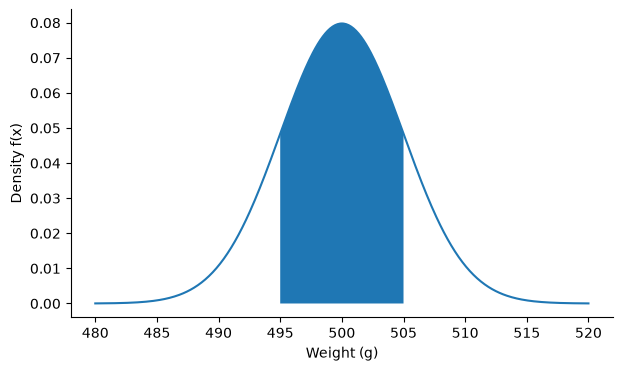

In [37]:
# Parameters
mu=500
sigma=5

# Particular interval
c=495
d=505

# Generate x-values

x=np.linspace(480,520,400)

# Calculate PDF
pdf=stats.norm.pdf(x,mu,sigma)
plt.plot(x,pdf)

x_interval=np.linspace(c,d,100)
pdf_interval = stats.norm.pdf(x_interval,mu,sigma)
plt.fill_between(x_interval, pdf_interval)

plt.xlabel("Weight (g)")
plt.ylabel("Density f(x)")
plt.show()

## Q5. Uniform distribution

### 📘 Theory
In a (continuous) **Uniform** distribution, every value between a minimum $a$ and a maximum $b$ is **equally likely**. There are no favourites, so the graph is a **flat rectangle**.

Examples: waiting for a bus that comes at regular intervals, a random number between 0 and 1, the arrival time of a delivery in a time window.

### 🧮 Maths
$$f(x) = \begin{cases} \dfrac{1}{b-a} & a \le x \le b \\[6pt] 0 & \text{otherwise} \end{cases}$$

The rectangle has width $b-a$ and height $\frac{1}{b-a}$, so its **area = 1** ✔.

Probability of any slice = area of a smaller rectangle:
$$P(c \le X \le d) = \frac{d - c}{b - a}$$

$$\text{Mean: } E[X] = \frac{a+b}{2} \qquad \text{Variance: } Var(X) = \frac{(b-a)^2}{12}$$

```
 f(x)
     │   ┌─────────────────┐  height = 1/(b−a)
     │   │█████            │
   0 ┼───┴─────┴───────────┴──── x
         a     d           b
```

### ❓ Scenario question
Write a Python program to generate 1,000 random numbers between 10 and 20 using a uniform distribution and plot their distribution

Text(0, 0.5, 'Density f(x)')

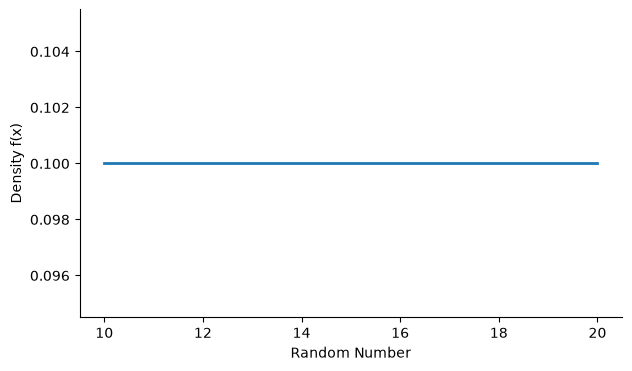

In [38]:
a=10
b=20
n=1000
x=np.linspace(a,b,n)
pdf = stats.uniform.pdf(x,loc=a,scale=(b-a))
plt.plot(x,pdf,lw=2)
plt.xlabel("Random Number")
plt.ylabel("Density f(x)")


---

### How to pick the distribution from a scenario
```
Is the value COUNTED or MEASURED?
│
├── COUNTED
│     ├── one yes/no trial? ──────────────────► Bernoulli
│     ├── successes in n fixed trials? ───────► Binomial
│     └── events in a time period / area? ────► Poisson
│
└── MEASURED
      ├── clusters around an average? ────────► Normal
      ├── all values in a range equally likely? ► Uniform

```